In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# %matplotlib widget
# plt.rc('text', usetex = True)
plt.rcParams['font.size'] = 16
# plt.rcParams['figure.facecolor'] = 'w'
# plt.style.use('classic')

In [3]:
def customCMAP(names = ['hot_r', 'cool', 'bone_r', 'pink_r', 'plasma_r'], ncolors: int = 256):

        for cmap in names:
            # if custom version of cmap already exists, skip it
            if cmap + 'T' in plt.colormaps():
                continue
            else:
            # create the colormap
                color_array = plt.get_cmap(cmap)(range(ncolors))
                color_array[:,-1] = np.power(np.linspace(0, 1.0, ncolors), 1/2) # adjusted so that the alpha increases quicker than linearly
                map_object = mcolors.LinearSegmentedColormap.from_list(name = cmap + 'T', colors = color_array)
                plt.colormaps.register(cmap = map_object)

customCMAP()

In [4]:
thicknesses = [ '0.5' , '2.0']
materials = ['Be', 'Al']

def entrance_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/entrance_window.csv'

def exit_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/exit_window.csv'

def LXe_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/LXe.csv'

def Silviu_entrance_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_entrance_window.csv'

def Silviu_exit_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_exit_window.csv'

def Silviu_LXe_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_LXe.csv'

In [5]:
entrance_data = [pd.read_csv(entrance_win_path(mat, thk))['EDD'].to_numpy() for thk in thicknesses for mat in materials]
exit_data = [pd.read_csv(exit_win_path(mat, thk))['EDD'].to_numpy() for thk in thicknesses for mat in materials]

In [6]:
[[mat,thk] for thk in thicknesses for mat in materials]

[['Be', '0.5'], ['Al', '0.5'], ['Be', '2.0'], ['Al', '2.0']]

<>:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_30797/1172055937.py:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.xlabel('Energy deposition density [$J\cdot g^{-1}$]', fontsize=18, labelpad=0.5)
/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_30797/1172055937.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp =plt.boxplot(exit_data, notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor': '

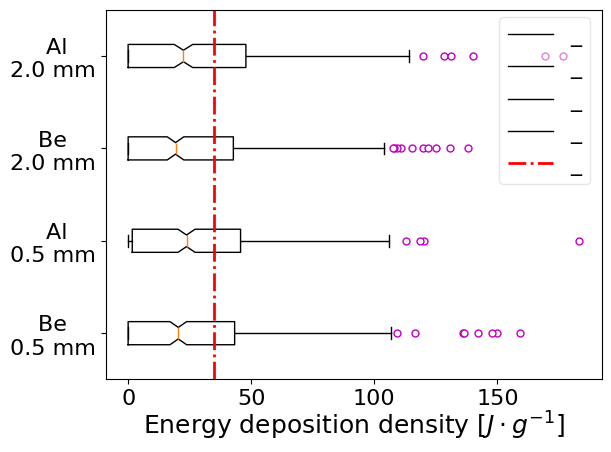

In [8]:
plt.close()
plt.figure()

# plt.rc('text', usetex = False)

bp =plt.boxplot(exit_data, notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor': 'white', 'markersize': 5}, labels=['Be    \n0.5 mm', 'Al    \n0.5 mm', 'Be    \n2.0 mm', 'Al    \n2.0 mm'], widths=0.25)
# bp =plt.boxplot([Al['EDD'].to_numpy(), Be['EDD'].to_numpy()], notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor': 'white', 'markersize': 5}, labels=['Aluminum', 'Beryllium'], widths=0.25)

plt.axvline(35, c='r', ls='-.', lw=2)


# plt.legend(['_' for i in range(28)] + [r'$\mathrm{Peak\ energy\ deposition\ density}$'], fontsize=18, loc='upper right', bbox_to_anchor=(1, 1.02))
# plt.xlabel(r'$\mathrm{Energy\ deposition\ density}\ \left[\ J\cdot g^{-1}\right]$', fontsize=18, labelpad=0.5)
plt.legend(['_' for i in range(28)] + ['Peak energy deposition density'], fontsize=16, loc='upper right', bbox_to_anchor=(1, 1.01), framealpha=0.5)
plt.xlabel('Energy deposition density [$J\cdot g^{-1}$]', fontsize=18, labelpad=0.5)
# plt.xlabel(r'Energy deposition density $\left[\ J\cdot g^{-1}\right]$', fontsize=18, labelpad=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/Exit_EDD_boxplot', ext='png', dpi=500)

plt.show()

<>:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_30797/1486343627.py:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.xlabel('Energy deposition density [$J\cdot g^{-1}$]', fontsize=18, labelpad=0.5)
/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_30797/1486343627.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp =plt.boxplot(entrance_data, notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor

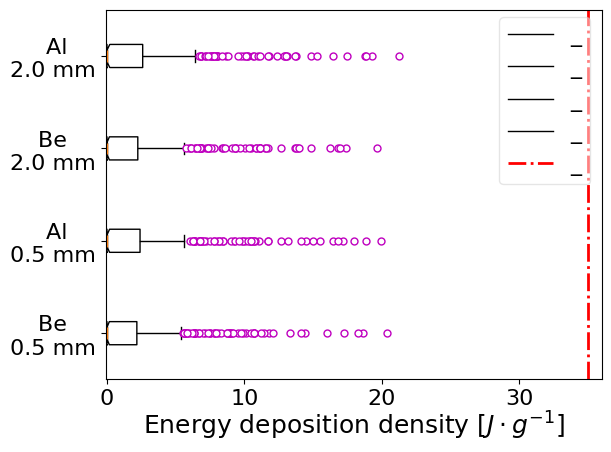

In [9]:
plt.close()
plt.figure()

# plt.rc('text', usetex = False)

bp =plt.boxplot(entrance_data, notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor': 'white', 'markersize': 5}, labels=['Be    \n0.5 mm', 'Al    \n0.5 mm', 'Be    \n2.0 mm', 'Al    \n2.0 mm'], widths=0.25)
# bp =plt.boxplot([Al['EDD'].to_numpy(), Be['EDD'].to_numpy()], notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor': 'white', 'markersize': 5}, labels=['Aluminum', 'Beryllium'], widths=0.25)

plt.axvline(35, c='r', ls='-.', lw=2)


# plt.legend(['_' for i in range(28)] + [r'$\mathrm{Peak\ energy\ deposition\ density}$'], fontsize=18, loc='upper right', bbox_to_anchor=(1, 1.02))
# plt.xlabel(r'$\mathrm{Energy\ deposition\ density}\ \left[\ J\cdot g^{-1}\right]$', fontsize=18, labelpad=0.5)
plt.legend(['_' for i in range(28)] + ['Peak energy deposition density'], fontsize=16, loc='upper right', bbox_to_anchor=(1, 1.01), framealpha=0.5)
plt.xlabel('Energy deposition density [$J\cdot g^{-1}$]', fontsize=18, labelpad=0.5)
# plt.xlabel(r'Energy deposition density $\left[\ J\cdot g^{-1}\right]$', fontsize=18, labelpad=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(-0.1, 36)
# plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/Entrance_EDD_boxplot', ext='png', dpi=500)

plt.show()

In [76]:
LXe_data = [pd.read_csv(LXe_path(mat, thk))['EDD'].to_numpy() for thk in thicknesses for mat in materials]
nonzero_LXe = [data[data != 0] for data in LXe_data]

/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_50292/968940190.py:8: UserWarning: The handle <matplotlib.lines.Line2D object at 0x7fa6b4fab5b0> has a label of '_nolegend_' which cannot be automatically added to the legend.
  plt.legend(['_nolegend_' for i in range(28)] + ['Peak energy deposition density'], fontsize=16, loc='upper left', bbox_to_anchor=(0, 1.01), framealpha=0.5)
/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_50292/968940190.py:8: UserWarning: The handle <matplotlib.lines.Line2D object at 0x7fa6b4fab880> has a label of '_nolegend_' which cannot be automatically added to the legend.
  plt.legend(['_nolegend_' for i in range(28)] + ['Peak energy deposition density'], fontsize=16, loc='upper left', bbox_to_anchor=(0, 1.01), framealpha=0.5)
/var/folders/l9/q33h82k16xx50gmpcg10_ymh0000gn/T/ipykernel_50292/968940190.py:8: UserWarning: The handle <matplotlib.lines.Line2D object at 0x7fa6b4fabb50> has a label of '_nolegend_' which cannot be automatically 

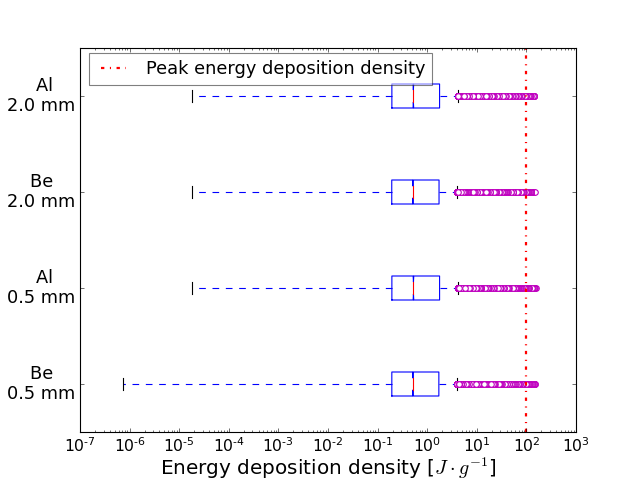

In [106]:
plt.close()
plt.figure()

bp =plt.boxplot(nonzero_LXe, notch=True, vert=False, flierprops={'marker': 'o', 'markeredgecolor': 'm', 'markerfacecolor': 'white', 'markersize': 5}, labels=['Be    \n0.5 mm', 'Al    \n0.5 mm', 'Be    \n2.0 mm', 'Al    \n2.0 mm'], widths=0.25)

plt.axvline(96.2, c='r', ls='-.', lw=2)
# plt.legend(['_nolegend_' for i in range(28)] + [r'$\mathrm{Peak\ energy\ deposition\ density}$'], fontsize=16, loc='upper left')
plt.legend(['_nolegend_' for i in range(28)] + ['Peak energy deposition density'], fontsize=16, loc='upper left', bbox_to_anchor=(0, 1.01), framealpha=0.5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=16)
plt.xscale('log')
# plt.xlabel(r'$\mathrm{Energy\ Deposition\ Density}\ \left[\ J\cdot g^{-1}\right]$', fontsize=18, labelpad=0.5)
plt.xlabel('Energy deposition density [$J\cdot g^{-1}$]', fontsize=18, labelpad=0.5)

plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/LXe_EDD_boxplot', ext='png', dpi=500)

plt.show()

In [112]:
LXe_above_PEDD = [[val for val in data if val > 96.2] for data in LXe_data]

print('Percentage of nonzero LXe EDD that is greater than PEDD:')
print([f'{len(LXe_above_PEDD[i]) / len(nonzero_LXe[i]) * 100:.2f} %' for i in range(len(LXe_above_PEDD))])

Percentage of nonzero LXe EDD that is greater than PEDD:
['0.36 %', '0.41 %', '0.41 %', '0.39 %']


### 0.5 mm Be imports

In [10]:
LXe = pd.read_csv(LXe_path('Be', '0.5'))
LXe_nonzero = LXe[LXe['EDD'] != 0]
NW = pd.read_csv(entrance_win_path('Be', '0.5'))
XW = pd.read_csv(exit_win_path('Be', '0.5'))

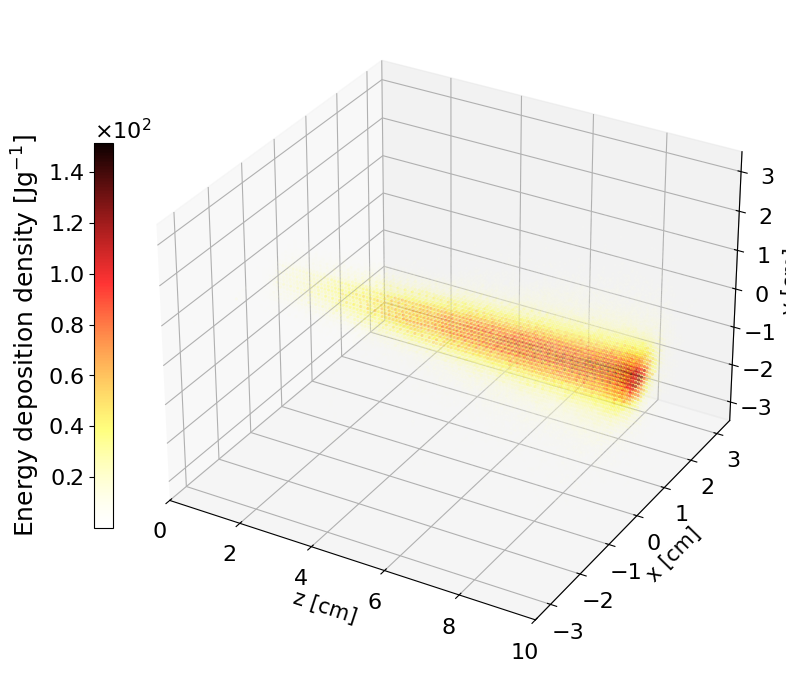

In [52]:
X,Y = np.meshgrid(np.unique(LXe['x']), np.unique(LXe['y']))

plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))#, constrained_layout=True)
# img = ax.scatter(LXe['z'], LXe['x'], LXe['y'], c=LXe['EDD'], marker='o', s=5, cmap='hot_rT', edgecolors='none')
img = ax.scatter(LXe_nonzero['z'], LXe_nonzero['x'], LXe_nonzero['y'], c=LXe_nonzero['EDD'], marker='o', s=5, cmap='hot_rT', edgecolors='none')
# ax.scatter(NW['z'], NW['x'], NW['y'], c=NW['EDD'], marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 4)
# ax.scatter(XW['z'], XW['x'], XW['y'], c=XW['EDD'], marker='o', s=5, cmap='coolT', edgecolors='none', vmax = 4)

cb = fig.colorbar(img, ax=ax, pad=0.01, shrink=.5, location='left')
cb.set_label('Energy deposition density [Jg$^{-1}$]', fontsize=18)

cb.formatter.set_useMathText(True)
cb.formatter.set_powerlimits((0, 0))

# ax.plot3D([10, 10], [3.5, 3.5], [-3.5, 3.5], c='k')
# ax.plot3D([10, 10], [-3.5, -3.5], [-3.5, 3.5], c='k')
# ax.plot3D([10, 10], [-3.5, 3.5], [3.5, 3.5], c='k')
# ax.plot3D([10, 10], [-3.5, 3.5], [-3.5, -3.5], c='k')

# ax.plot3D([0, 0], [3.5, 3.5], [-3.5, 3.5], c='k')
# ax.plot3D([0, 0], [-3.5, -3.5], [-3.5, 3.5], c='k')
# ax.plot3D([0, 0], [-3.5, 3.5], [3.5, 3.5], c='k')
# ax.plot3D([0, 0], [-3.5, 3.5], [-3.5, -3.5], c='k')

# ax.plot3D([0, 10], [-3.5, -3.5], [-3.5, -3.5], c='k')
# ax.plot3D([0, 10], [-3.5, -3.5], [3.5, 3.5], c='k')
# ax.plot3D([0, 10], [3.5, 3.5], [-3.5, -3.5], c='k')
# ax.plot3D([0, 10], [3.5, 3.5], [3.5, 3.5], c='k')

ax.set_xlabel('z [cm]', fontsize=15)
ax.set_ylabel('x [cm]', fontsize=15)
ax.set_zlabel('y [cm]', fontsize=15)

ax.set_xlim(0, 10)
ax.set_ylim(-3.5, 3.5)
ax.set_zlim(-3.5, 3.5)

# fig.tight_layout()
plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/LXe_EDD_scatterplot.png', dpi=500)

plt.show()

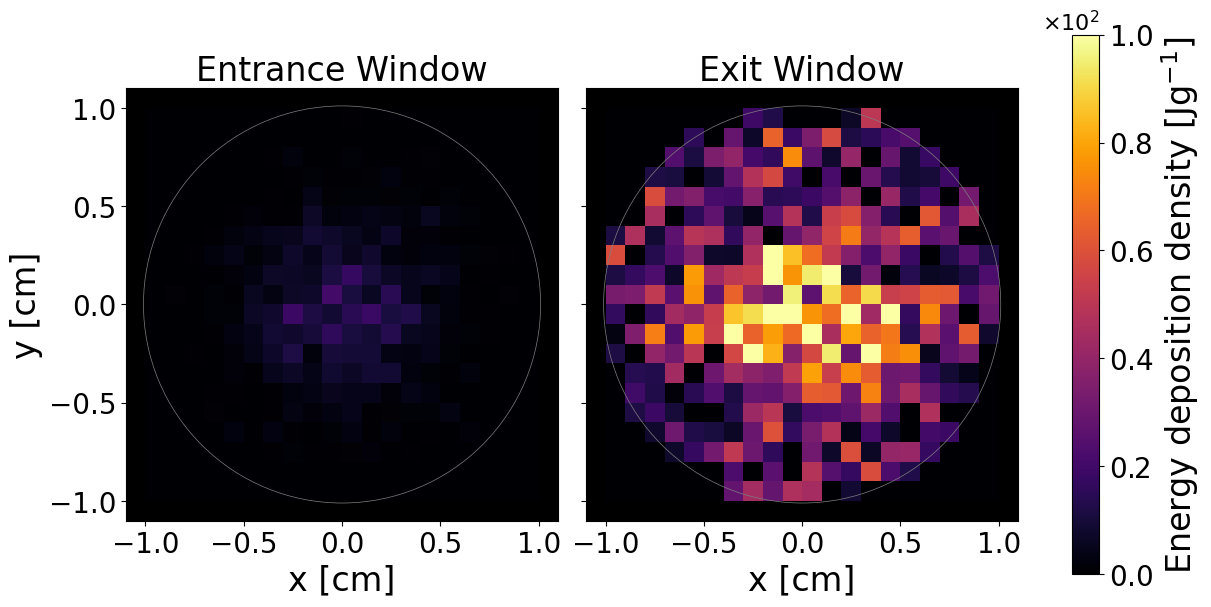

In [33]:
from matplotlib.patches import Circle

names = ['Entrance Window', 'Exit Window']
# label = r'$\mathrm{Energy\ Deposition\ Density}\ \left[\ J\cdot g^{-1}\right]$'
label = 'Energy deposition density [Jg$^{-1}$]'
WinEDD = [
    NW,
    XW
    ]

vmin = 0
vmax = 1e2
n = 20 # n by n grid

plt.close()
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12,6), constrained_layout=True)

for i in range(2):
    im = ax[i].pcolormesh(WinEDD[i]['x'].to_numpy().reshape(n,n), WinEDD[i]['y'].to_numpy().reshape(n,n), WinEDD[i]['EDD'].to_numpy().reshape(n,n).T,
        cmap='inferno',
        vmin=vmin,
        vmax=vmax,
    )

    ######################################

    # outline the window edges, with a slight fudge factor to endsure we aren't excluding any hits in the EDD calculations later on
    circ = ax[i].add_patch(Circle((0,0), radius=1.0 + 1e-2, facecolor='None', edgecolor='gray', lw=0.5))

    ######################################
    
    # ax[i].autoscale_view()
    ax[i].set_xlabel('x [cm]', fontsize=24)
    # ax[i].set_xticks(np.arange(-1,1.25,0.25))
    # ax[i].set_yticks(np.arange(-1,1.25,0.25))
    ax[i].set_xlim(-1.1,1.1)
    ax[i].set_title(names[i], fontsize=24)
    ax[i].set_aspect('equal')
    ax[i].set_facecolor('black')
    ax[i].tick_params(axis='x', labelsize=20)
ax[0].set_ylabel('y [cm]', fontsize=24)
ax[0].set_ylim(-1.1,1.1)
ax[0].set_yticks(np.arange(-1,1.5,0.5))
ax[0].tick_params(axis='y', labelsize=20)
cb = plt.colorbar(im, ax=ax[1], # pad=0.0,
                # , extend='max'
                )
cb.set_label(label=label, fontsize=24)
cb.ax.tick_params(labelsize=20)
cb.formatter.set_useMathText(True)
cb.formatter.set_powerlimits((0, 0))

plt.savefig('/Users/max/SLAC Fall 2024/LXeSims'+f'/Figures/Be_0.5mm_EDD.pdf', dpi=500)

plt.show()

### Get distribution from exit window

In [ ]:
SNW = pd.read_csv(Silviu_entrance_win_path('Al', '2.0'))
SXW = pd.read_csv(Silviu_exit_win_path('Al', '2.0'))

In [15]:
from scipy.optimize import curve_fit

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, theta):
    # ... (implementation of 2D Gaussian function)
    # This involves rotation and standard Gaussian calculation
    # For a simplified version, assume no rotation (theta = 0)
    x, y = xy
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    return amplitude * np.exp(-(a*(x-x0)**2 + 2*b*(x-x0)*(y-y0) + c*(y-y0)**2))

def truncated_gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, theta, x1, y1):
    x, y = xy
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    return amplitude * np.exp(-(a*(x-x0)**2 + 2*b*(x-x0)*(y-y0) + c*(y-y0)**2)) * np.heaviside(x1-abs(x), 1.0)* np.heaviside(y1-abs(y), 0.5)

def spherical_z(x, y, z, radius):
    # everything in meters
    return np.sqrt(radius**2 - x**2 - y**2) - (radius - z) - (np.sqrt(radius**2 - 2 * 0.035**2) - radius)

# def z_correction(x, y, z, radius):
#     return spherical_z(x, y, z, radius) - (spherical_z(3.5, 3.5, 0., radius) - spherical_z(0., 0., 0., radius))


In [20]:
radius = 17.5
print(-(np.sqrt(radius**2 - 2 * 3.5**2) - radius))
spherical_z(0.035, 0.035, 0.101, 0.175)

0.7145896684054804


0.101

In [444]:
xy = np.vstack([SXW['x'], SXW['y']])

In [449]:
initial_guess = (np.max(SXW['PowerPerVolume']), 0.0, 0.0, 0.2e-2, 0.2e-2, 0)
params, covariance = curve_fit(gaussian_2d, xy, SXW['PowerPerVolume'], p0=initial_guess)

T_initial_guess = (np.max(SXW['PowerPerVolume']), 0.0, 0.0, 0.2e-2, 0.2e-2, 0, 1e-2, 1e-2)
T_params, T_covariance = curve_fit(truncated_gaussian_2d, xy, SXW['PowerPerVolume'], p0=T_initial_guess)

In [450]:
print(params)
print(T_params)

[ 3.80128737e+09 -3.11565313e-04 -2.50757225e-06  5.17307955e-03
  4.35350610e-03  1.13678499e-01]
[ 3.80128737e+09 -3.11565313e-04 -2.50757225e-06  5.17307955e-03
  4.35350610e-03  1.13678499e-01  1.00000000e-02  1.00000000e-02]


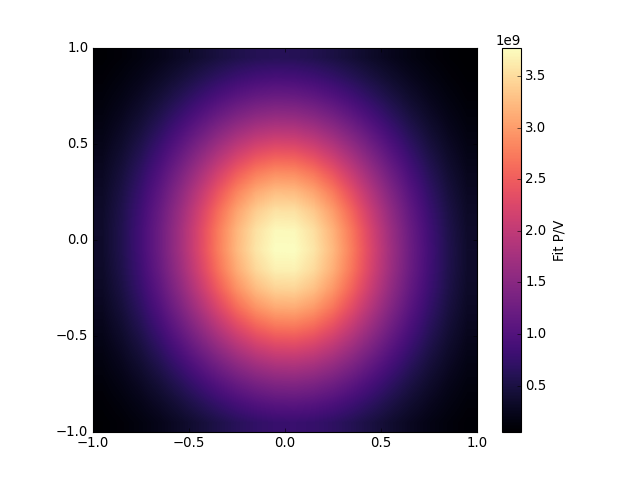

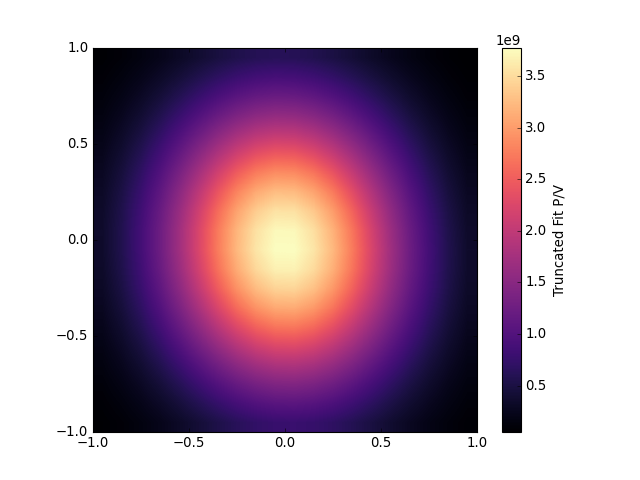

In [451]:
plt.close()
plt.figure()
fitted_surface = gaussian_2d(xy, *params).reshape((n,n))
plt.imshow(fitted_surface.T, origin='lower', extent=[-1.0, 1.0, -1.0, 1.0], alpha=1.0, cmap='magma')
plt.colorbar(label='Fit P/V')
plt.show()

plt.close()
plt.figure()
T_fitted_surface = truncated_gaussian_2d(xy, *T_params).reshape((n,n))
plt.imshow(T_fitted_surface.T, origin='lower', extent=[-1.0, 1.0, -1.0, 1.0], alpha=1.0, cmap='magma')
plt.colorbar(label='Truncated Fit P/V')
plt.show()

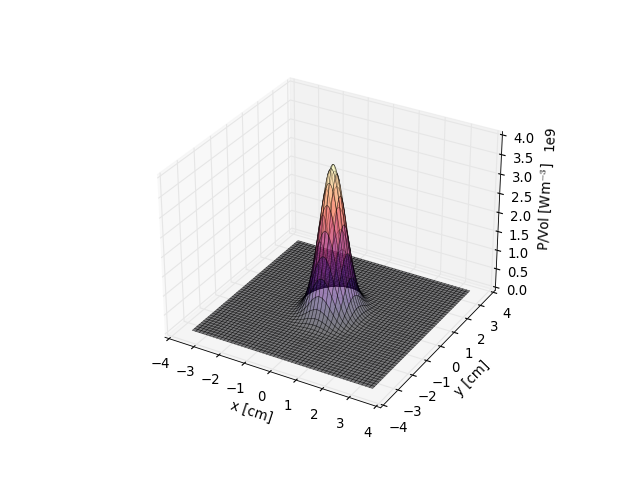

In [455]:
plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

N = 500
domain = np.linspace(-3.5 , 3.5, N)
X,Y = np.meshgrid(domain, domain)
surf = gaussian_2d(np.vstack([X.ravel() * 1e-2,Y.ravel() * 1e-2]), *params).reshape(N,N)

ax.plot_surface(X, Y, surf.T, alpha=0.5, cmap='magma', linewidth=0.5, edgecolor='black')
# ax.plot_surface(XW['x'].to_numpy().reshape(n,n), XW['y'].to_numpy().reshape(n,n), fitted_surface.T, alpha=0.5)

ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_zlabel('P/Vol [Wm$^{-3}$]')

plt.show()

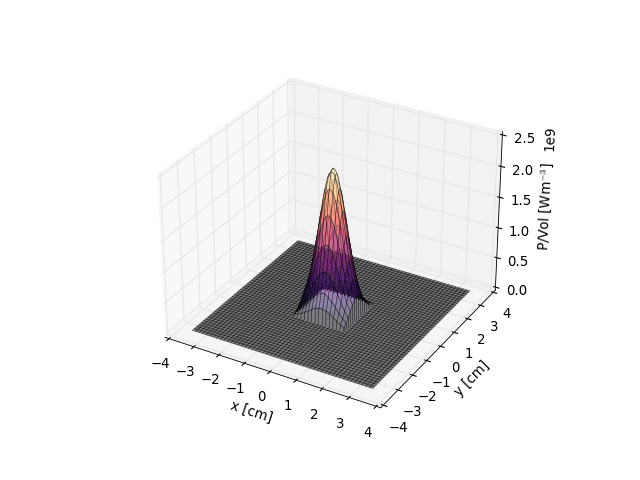

In [417]:
plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

N = 500
domain = np.linspace(-3.5 , 3.5, N)
X,Y = np.meshgrid(domain, domain)
T_surf = truncated_gaussian_2d(np.vstack([X.ravel() * 1e-2,Y.ravel() * 1e-2]), *T_params).reshape(N,N)

ax.plot_surface(X, Y, T_surf.T, alpha=0.5, cmap='magma', linewidth=0.5, edgecolor='black')
# ax.plot_surface(XW['x'].to_numpy().reshape(n,n), XW['y'].to_numpy().reshape(n,n), fitted_surface.T, alpha=0.5)

ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_zlabel('P/Vol [Wm$^{-3}$]')

plt.show()

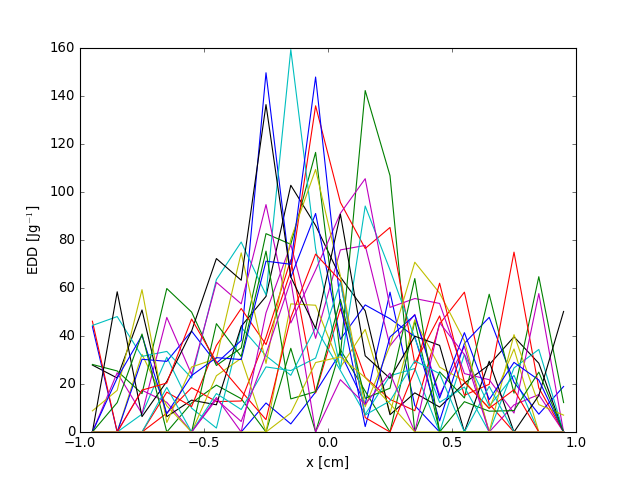

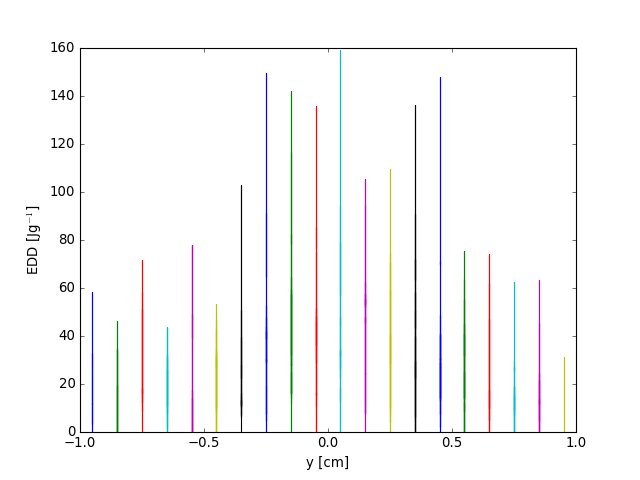

In [ ]:
plt.close()
plt.figure()

for i in range(n):
    plt.plot(XW['x'][i*n:(i+1)*n], XW['EDD'][i*n:(i+1)*n])

plt.xlabel('x [cm]')
plt.ylabel('EDD [Jg$^{-1}$]')

plt.show()

plt.close()
plt.figure()

for i in range(n):
    plt.plot(XW['y'][i*n:(i+1)*n], XW['EDD'][i*n:(i+1)*n])

plt.xlabel(' [cm]')
plt.ylabel('EDD [Jg$^{-1}$]')

plt.show()